In [29]:
import os
os.environ["PYART_QUIET"] = "True"  # Disable Py-ART warnings
import glob
import warnings

import pyart
import numpy as np
import ultraplot as pplt
import matplotlib.pyplot as plt
import opol_processing

In [3]:
infile = "/home/vlouf/Downloads/processed/20240626/9776HUB-PPIVol-20240626-120600-1984.cfradial.nc"
radar = pyart.io.read_cfradial(infile)
gr = pyart.graph.RadarDisplay(radar)
print("\n".join(radar.fields.keys()))

cross_correlation_ratio
temperature
corrected_reflectivity
corrected_differential_phase
corrected_specific_differential_phase
corrected_velocity
attenuation_corrected_reflectivity
corrected_differential_reflectivity
path_integrated_differential_attenuation
radar_echo_classification
radar_estimated_rain_rate
normalized_intercept_parameter
median_volume_diameter
radar_estimated_snow_rate
total_power
reflectivity
differential_reflectivity
velocity
differential_phase
signal_to_noise_ratio
spectrum_width
signal_quality_index


In [ ]:
def find_sweep_elevation(radar, target_elevation):
    """
    Find the sweep index that is closest to the target elevation.
    """
    elevations = radar.fixed_angle['data']
    sweep_index = np.argmin(np.abs(elevations - target_elevation))
    return sweep_index

In [26]:
gf = pyart.filters.GateFilter(radar)
gf.exclude_invalid("total_power")

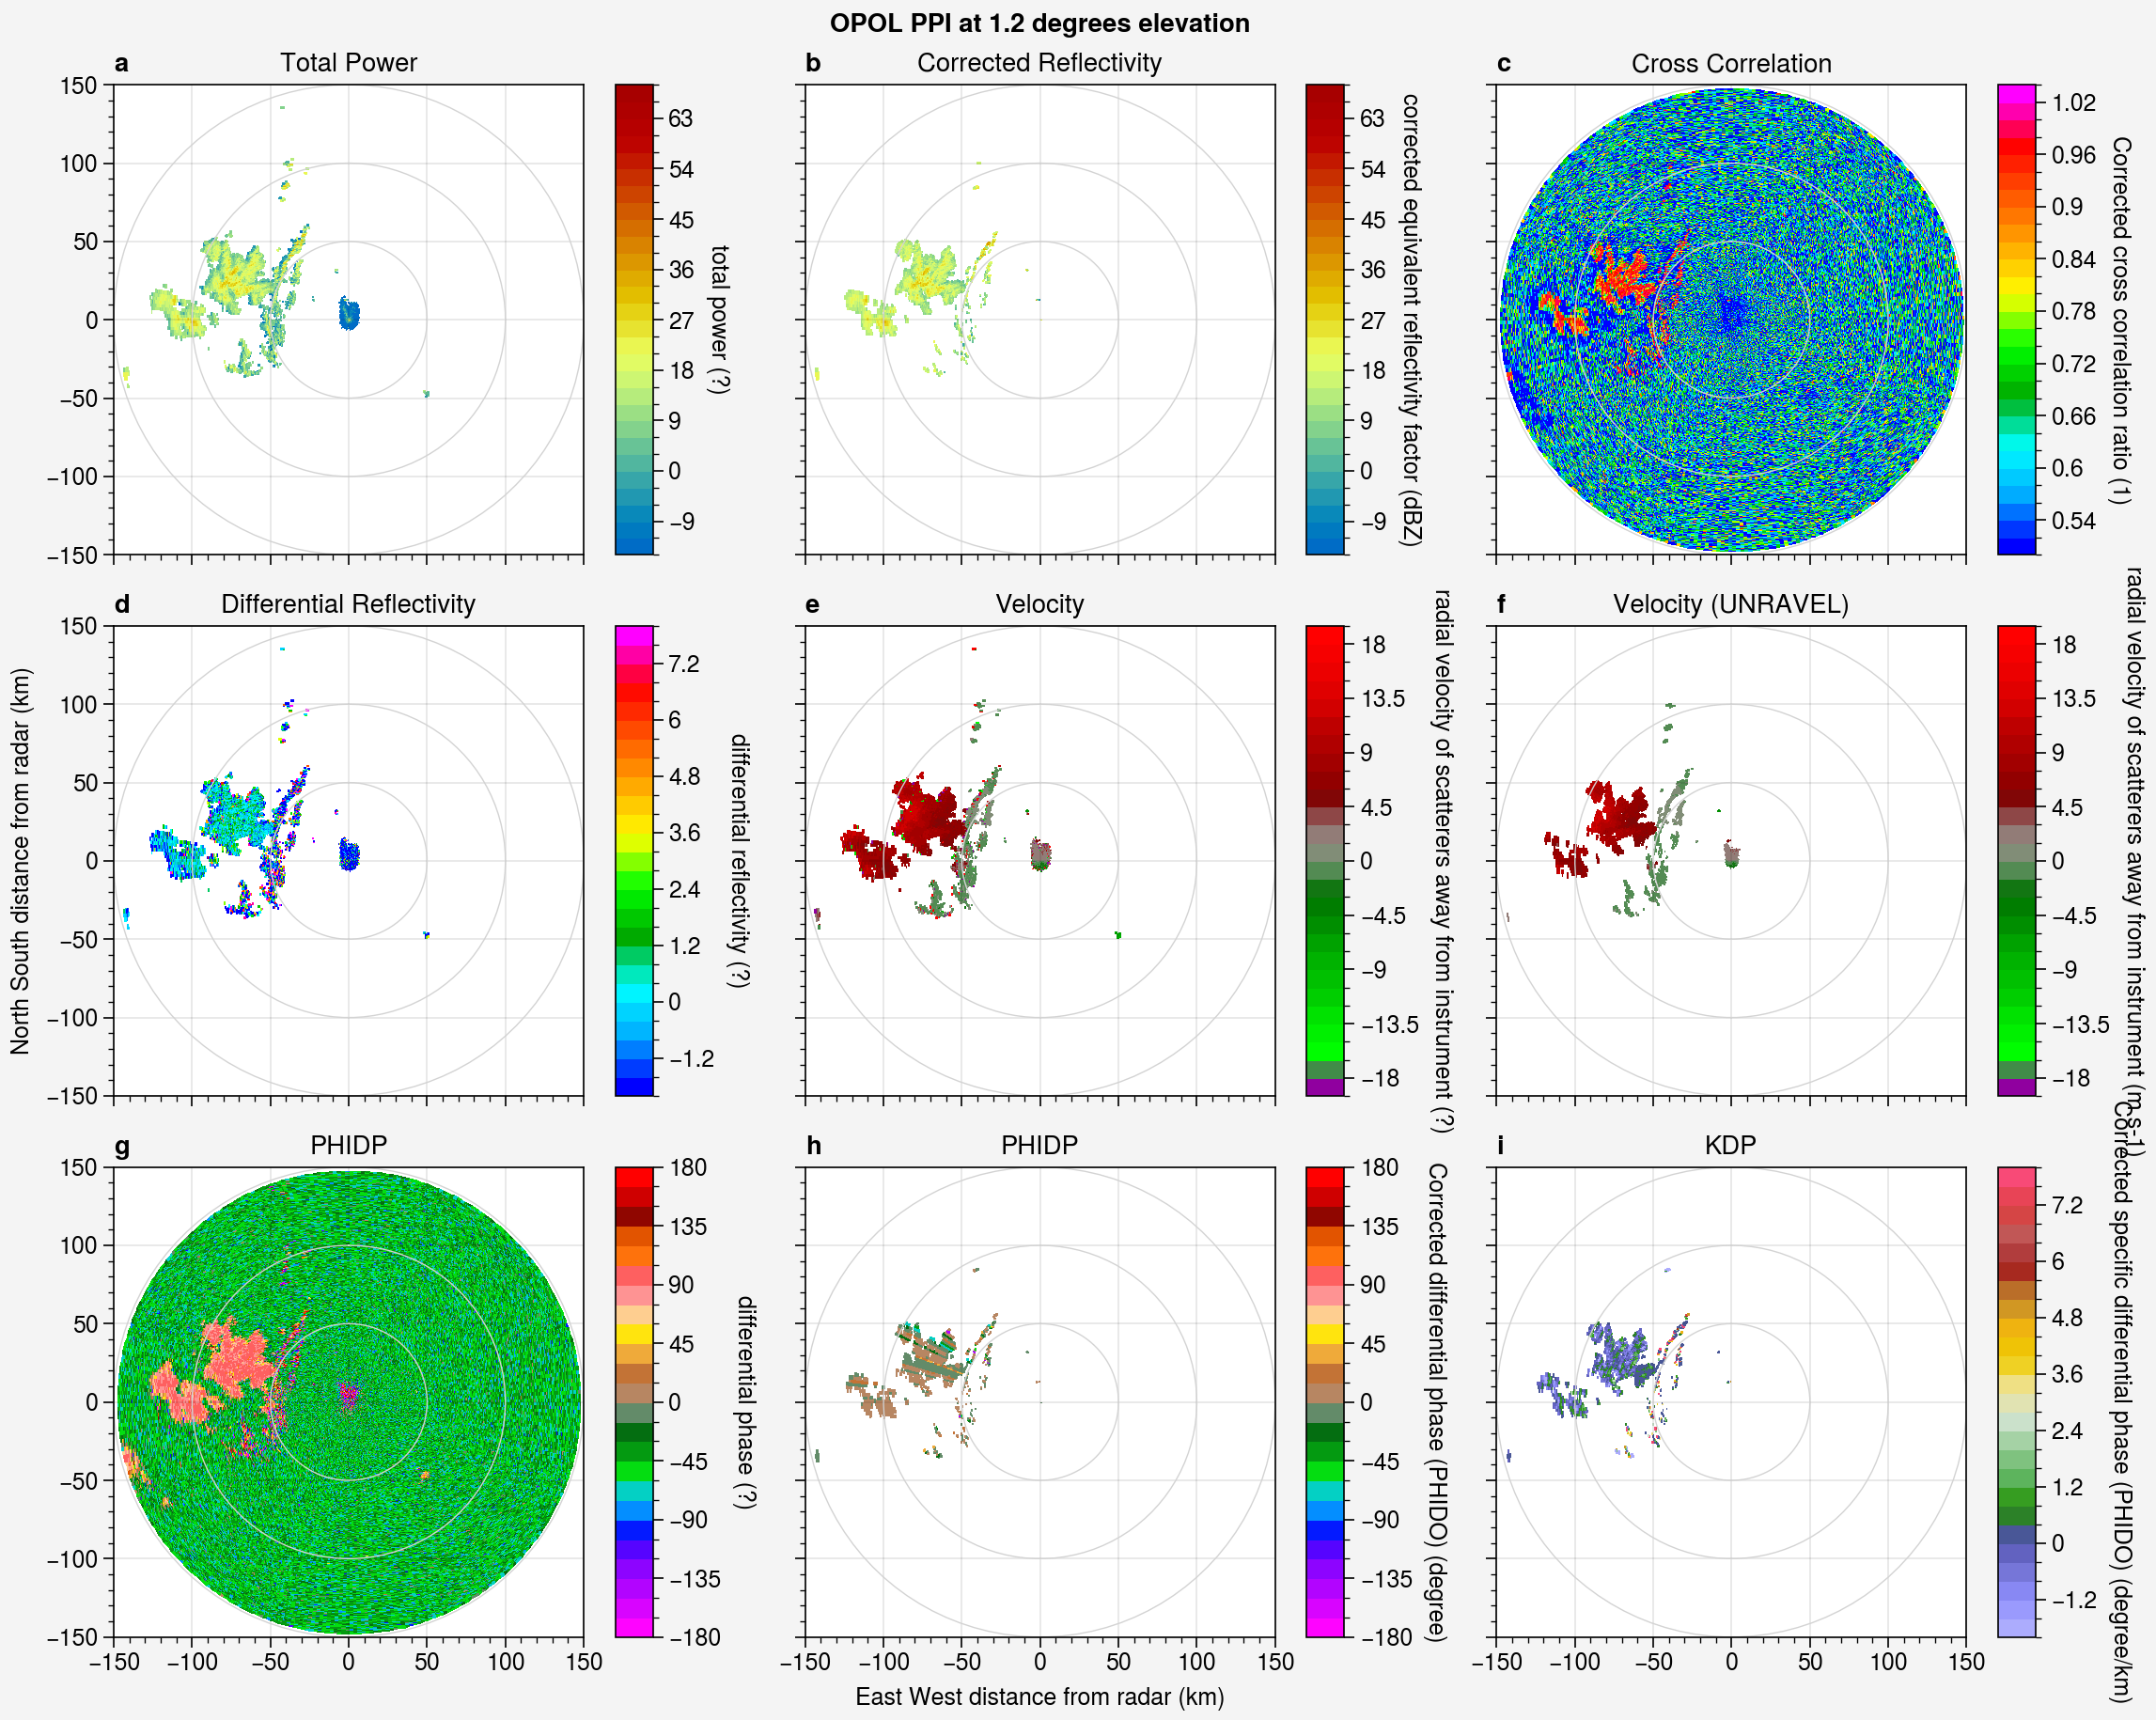

In [27]:
fig = pplt.figure()
axs = fig.subplots(nrows=3, ncols=3)
im = [None] * len(axs)
sw = find_sweep_elevation(radar, 1.2)  # Get the sweep index for 1.2 degrees elevation

gr.plot_ppi('total_power', ax=axs[0], title='Total Power', vmin=-15, vmax=70, cmap="HomeyerRainbow", sweep=sw, levels=32)
gr.plot_ppi('corrected_reflectivity', ax=axs[1], title='Corrected Reflectivity', vmin=-15, vmax=70, cmap="HomeyerRainbow", sweep=sw, levels=32)
gr.plot_ppi('cross_correlation_ratio', ax=axs[2], title='Cross Correlation', vmin=0.5, vmax=1.05, cmap="RefDiff", sweep=sw, levels=32)

gr.plot_ppi('differential_reflectivity', ax=axs[3], title='Differential Reflectivity', vmin=-2, vmax=8, cmap="RefDiff", sweep=sw, levels=32, gatefilter=gf)
gr.plot_ppi('velocity', ax=axs[4], title='Velocity', vmin=-20, vmax=20, cmap="NWSVel", sweep=sw, levels=32, gatefilter=gf)
gr.plot_ppi('corrected_velocity', ax=axs[5], title='Velocity (UNRAVEL)', vmin=-20, vmax=20, cmap="NWSVel", sweep=sw, levels=32)

gr.plot_ppi('differential_phase', ax=axs[6], title='PHIDP', vmin=-180, vmax=180, cmap="Wild25", sweep=sw, levels=32)
gr.plot_ppi('corrected_differential_phase', ax=axs[7], title='PHIDP', vmin=-180, vmax=180, cmap="Wild25", sweep=sw, levels=32)
gr.plot_ppi('corrected_specific_differential_phase', ax=axs[8], title='KDP', vmin=-2, vmax=8, cmap="Theodore16", sweep=sw, levels=32)

for a in axs:
    gr.plot_range_rings([50, 100, 150], ax=a, col='lightgray', ls='-', lw=0.5)

axs.format(abc=True, grid=True, suptitle="OPOL PPI at 1.2 degrees elevation", xlim=(-150, 150), ylim=(-150, 150), aspect='equal')
plt.show()